In [4]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.custom_langevin import CustomLangevin
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter, NelsonAalenFitter
import multiprocessing as mp
mp.set_start_method("fork", force=True)   # must be the first multiprocessing call


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## with dimensions

In [5]:
# Create the CustomLangevin simulator
print("Setting up the Langevin simulator...")
langevin_sim = CustomLangevin(
    n=10000,           # Number of trajectories
    dt=0.05,            # Time step of 0.1 as requested
    save_paths=True,   # Save trajectories for plotting
    save_interval=1.0, # Save every 1 time unit
    parallel=False      # Use parallel processing
)

# Define your SDE - Fixed the parsing issue
# dx/dt = 2*alpha*x - 3*beta_0 / (1-gamma*t) * x^2 + sqrt(2*eps)*noise
print("Setting the SDE...")
noise_str = "sqrt(2*eps)"
drift_str = "2*alpha*y - 3*beta_0*y**2 / (1 - gam*t)"

langevin_sim.set_sde(drift_str=drift_str, noise_str=noise_str)

# Set your parameter values
params = {
    'alpha': 1.0,
    'beta_0': 1.2,
    'eps': 0.01,
    'gam': 1.01e-2
}

print(f"Using parameters: {params}")
y0 = 2/3 * (params['alpha']/params['beta_0'])


# Run the simulation
print("Running simulation...")
langevin_sim.run_simulation(
    y0=y0,              # Initial condition (you can adjust this)
    tmax=100.0,          # Simulate from 1 to 100 (actually 0 to 100)
    death_threshold=0.0, # Death occurs when x crosses below 0
    params=params
)



Setting up the Langevin simulator...
Setting the SDE...
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Using parameters: {'alpha': 1.0, 'beta_0': 1.2, 'eps': 0.01, 'gam': 0.0101}
Running simulation...
Simulation and analysis complete.


SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values w

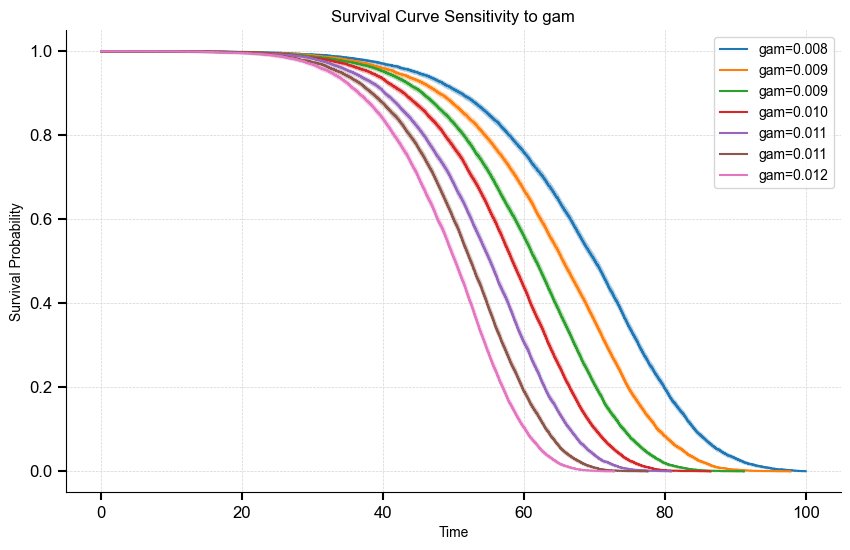

In [14]:
def plot_hazard_sensitivity(param_name, base_params, factors=None, ax=None, plot_type='hazard'):
    """
    Plot hazard rates or survival curves for different parameter values.
    
    Args:
        param_name (str): Name of parameter to vary ('alpha', 'beta_0', etc.)
        base_params (dict): Base parameter dictionary
        factors (array-like): Multiplication factors for the parameter
        ax: matplotlib axes object. If None, creates new figure.
        plot_type (str): Either 'hazard' or 'survival' to specify plot type
    
    Returns:
        matplotlib axes object
    """
    if factors is None:
        factors = np.linspace(0.7, 1.3, 7)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Set font to Arial
    plt.rcParams['font.family'] = 'Arial'
    
    for factor in factors:
        # Create modified parameters
        params_modified = base_params.copy()
        params_modified[param_name] = base_params[param_name] * factor
        
        # Create new simulator
        sim = CustomLangevin(
            n=10000,
            dt=0.05,
            save_paths=True,
            save_interval=1.0,
            parallel=False
        )
        
        # Set SDE
        noise_str = "sqrt(2*eps)"
        drift_str = "2*alpha*y - 3*beta_0*y**2 / (1 - gam*t)"
        sim.set_sde(drift_str=drift_str, noise_str=noise_str)
        
        # Calculate initial condition
        y0 = 2/3 * (params_modified['alpha']/params_modified['beta_0'])
        
        # Run simulation
        sim.run_simulation(
            y0=y0,
            tmax=100.0,
            death_threshold=0.0,
            params=params_modified
        )
        
        # Create label for this parameter value
        label = f'{param_name}={params_modified[param_name]:.3f}'
        
        # Plot based on type
        if plot_type == 'hazard':
            sim.plot_hazard(ax=ax, label=label)
            ax.set_title(f'Hazard Rate Sensitivity to {param_name}')
            ax.set_ylabel('Hazard Rate')
        elif plot_type == 'survival':
            sim.plot_survival(ax=ax, label=label)
            ax.set_title(f'Survival Curve Sensitivity to {param_name}')
            ax.set_ylabel('Survival Probability')
        else:
            raise ValueError("plot_type must be either 'hazard' or 'survival'")
    
    ax.set_xlabel('Time')
    ax.legend()
    ax.grid(True, color='lightgrey', linestyle='--', linewidth=0.5)
    
    return ax

# Plot hazard sensitivity for alpha
factors = np.linspace(0.8, 1.2, 7)
ax = plot_hazard_sensitivity('gam', params, factors, plot_type='survival')
plt.show()


In [21]:
base_params = {
    'alpha': 1.0,
    'beta_0': 1.2,
    'eps': 0.01,
    'gam': 1.01e-2
}

def plot_steepness_vs_median(param_name, base_params = base_params, factors=None, ax=None):
    """
    Plot steepness vs median lifespan for different parameter values.
    
    Args:
        param_name (str): Name of parameter to vary ('alpha', 'beta_0', etc.)
        base_params (dict): Base parameter dictionary
        factors (array-like): Multiplication factors for the parameter
        ax: matplotlib axes object. If None, creates new figure.
    
    Returns:
        matplotlib axes object
    """
    if factors is None:
        factors = np.linspace(0.7, 1.3, 7)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Set font to Arial
    plt.rcParams['font.family'] = 'Arial'
    
    steepness_values = []
    median_values = []
    
    # First, get baseline values for factor = 1.0
    baseline_params = base_params.copy()
    sim_baseline = CustomLangevin(
        n=50000,
        dt=0.1,
        save_paths=False,
        save_interval=1.0,
        parallel=False
    )
    
    # Set SDE
    noise_str = "sqrt(2*eps)"
    drift_str = "2*alpha*y - 3*beta_0*y**2 / (1 - gam*t)"
    sim_baseline.set_sde(drift_str=drift_str, noise_str=noise_str)
    
    # Calculate initial condition
    y0_baseline = 2/3 * (baseline_params['alpha']/baseline_params['beta_0'])
    
    # Run baseline simulation
    sim_baseline.run_simulation(
        y0=y0_baseline,
        tmax=100.0,
        death_threshold=0.0,
        params=baseline_params
    )
    
    baseline_steepness = sim_baseline.steepness
    baseline_median = sim_baseline.median_t
    
    for factor in factors:
        # Create modified parameters
        params_modified = base_params.copy()
        params_modified[param_name] = base_params[param_name] * factor
        
        # Create new simulator
        sim = CustomLangevin(
            n=50000,
            dt=0.1,
            save_paths=True,
            save_interval=1.0,
            parallel=False
        )
        
        # Set SDE
        sim.set_sde(drift_str=drift_str, noise_str=noise_str)
        
        # Calculate initial condition
        y0 = 2/3 * (params_modified['alpha']/params_modified['beta_0'])
        
        # Run simulation
        sim.run_simulation(
            y0=y0,
            tmax=100.0,
            death_threshold=0.0,
            params=params_modified
        )
        
        # Store steepness and median values
        steepness_values.append(sim.steepness)
        median_values.append(sim.median_t)
    
    # Normalize by baseline values
    steepness_normalized = np.array(steepness_values) / baseline_steepness
    median_normalized = np.array(median_values) / baseline_median
    
    # Create scatter plot
    ax.scatter(median_normalized, steepness_normalized, 
               label=f'{param_name} sensitivity', s=150)
    
    ax.set_xlabel('Normalized Median Lifespan')
    ax.set_ylabel('Normalized Steepness')
    ax.set_title(f'Steepness vs Median Lifespan Sensitivity to {param_name}')
    ax.grid(True, color='lightgrey', linestyle='--', linewidth=0.5)
    
    return ax




SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values when calling run_simulation().
Simulation and analysis complete.
SDE set.
Identified parameters: ['alpha', 'beta_0', 'eps', 'gam']
Provide their values w

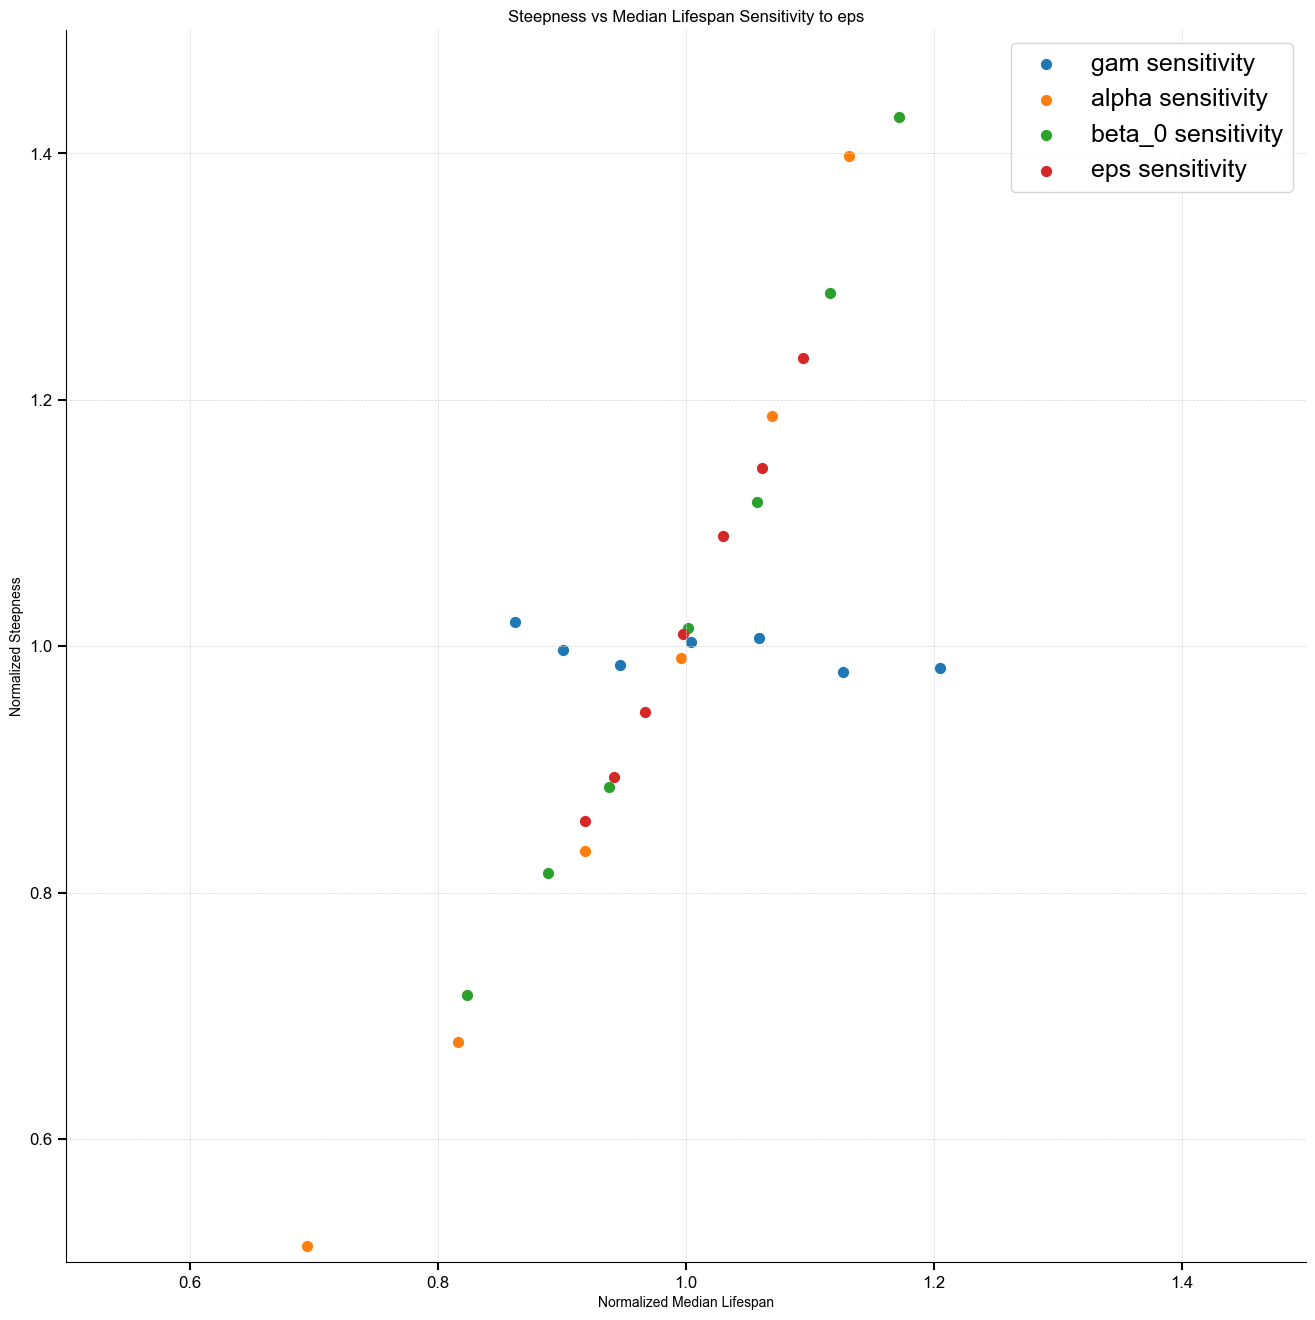

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(16, 16))
# Plot steepness vs median sensitivity for gamma
factors = np.linspace(0.8, 1.2, 7)
plot_steepness_vs_median('gam', base_params, factors, ax)
plot_steepness_vs_median('alpha', base_params, factors, ax)
plot_steepness_vs_median('beta_0', base_params, factors, ax)
plot_steepness_vs_median('eps', base_params, factors, ax)

ax.set_xlim(0.5, 1.5)
ax.set_ylim(0.5, 1.5)
ax.legend(fontsize=18)



## without dimensions


In [22]:
# Create the CustomLangevin simulator
print("Setting up the Langevin simulator...")
langevin_sim = CustomLangevin(
    n=10000,           # Number of trajectories
    dt=0.05,            # Time step of 0.05
    save_paths=True,   # Save trajectories for plotting
    save_interval=1.0, # Save every 1 time unit
    parallel=False      # Use parallel processing
)

# Define your SDE in dimensionless form
# dX/dτ = 2X - 2(1-λτ)^(-1/2)X^2 + sqrt(2D)*noise
print("Setting the SDE...")
noise_str = "sqrt(2*D)"
drift_str = "2*y - 2*y**2 / sqrt(1 - lam*t)"

langevin_sim.set_sde(drift_str=drift_str, noise_str=noise_str)

# Set dimensionless parameter values
params = {
    'lam': 0.01013,    # δ = γ/α
    'D': 0.03215       # ε̃ = 9β₀²ε/(4α³)
}

print(f"Using dimensionless parameters: {params}")
print(f"sqrt(2*D) ≈ {(2*params['D'])**0.5:.3f}")
y0 = 1


# Run the simulation
print("Running simulation...")
langevin_sim.run_simulation(
    y0=y0,              # Initial condition
    tmax=100.0,          # Simulate from 0 to 100
    death_threshold=0.0, # Death occurs when X crosses below 0
    params=params
)


Setting up the Langevin simulator...
Setting the SDE...
SDE set.
Identified parameters: ['D', 'lam']
Provide their values when calling run_simulation().
Using dimensionless parameters: {'lam': 0.01013, 'D': 0.03215}
sqrt(2*D) ≈ 0.254
Running simulation...
Simulation and analysis complete.
